### **Predictive Analysis: 6-Month ED Return**

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score
import xgboost as xgb



### **Research**
### **Can heart-failure severity, comorbidity burden, kidney function, and vital signs help predict whether a patient returns to the emergency department within six months?**

##### ***Reasoning : Patients with more severe heart failure, multiple comorbidities, impaired kidney function, or abnormal vital signs may have greater clinical complexity after discharge. Analyzing these markers can help determine whether they contain useful information for predicting future ED return.***
##### ***This analysis can help identify patterns associated with ED return and evaluate whether these clinical characteristics can collectively distinguish higher-risk patients.***

### **Hypothesis**
### **H₀ — Null hypothesis**
### **Heart-failure severity, comorbidity burden, kidney function, and vital signs do not provide meaningful predictive information for 6-month ED return.**

### **H₁ — Alternative hypothesis**
### **At least one of these clinical markers provides meaningful information related to 6-month ED return and may contribute to prediction.**

In [15]:
features = [
    "nyha_cardiac_function_classification",
    "lvef",
    "cci_score",
    "creatinine",
    "gfr",
    "pulse",
    "respiration",
    "systolic_bp",
    "diastolic_bp"
]

target = "ed_return_6mo"

### ***Selecting these markers nyha_cardiac_function_classification represents functional severity, levf(Cardiac Function) measures pumping function, cci_score for comorbidity burden, creatinine and gfr useful for kidney functioning. some vital signs heart rate,respiratory,systolic_bp and diastolic_bp***

In [16]:
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
# Creating a copy of the data to work on, so the original data is not modified
df = hf_df.copy()

ed_return_6mo
0.0    1232
1.0     775
Name: count, dtype: int64
ed_return_6mo
0.0    61.39
1.0    38.61
Name: proportion, dtype: float64


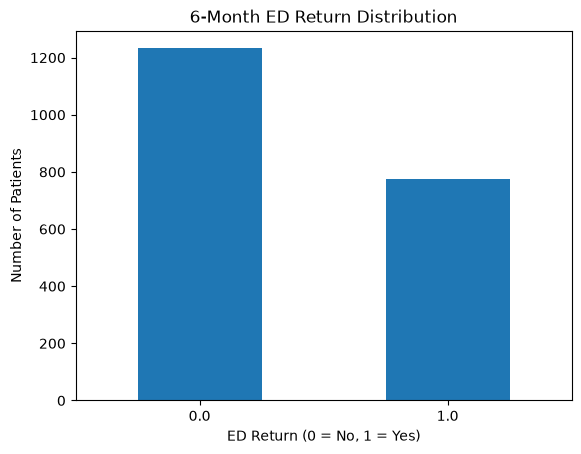

In [17]:
#Understanding how many patients returned to the ED
print(hf_df[target].value_counts())

print(
    hf_df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
hf_df[target].value_counts().sort_index().plot(kind="bar")

plt.title("6-Month ED Return Distribution")
plt.xlabel("ED Return (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

##### ***Dataset has both ED-return and non-return patients, allowing us to investigate which clincial characteristics differ between the two groups and whether those characteristics can be used for prediction***

### **Hypothesis Testing**
### **NYHA Severity**
### **H₀ - NYHA cardiac classification and 6-month ED return are independent.**
### **H₁ - NYHA cardiac classification is significantly associated with 6-month ED return**


In [18]:

# chi-square test
table = pd.crosstab(
    hf_df["nyha_cardiac_function_classification"],
    hf_df[target]
)

display(table)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", round(chi2, 3))
print("P-value:", round(p, 5))

if p < 0.05:
    print("Reject H0: Significant association exists.")
else:
    print("Fail to reject H0: No significant association found.")



ed_return_6mo,0.0,1.0
nyha_cardiac_function_classification,,
2,253,100
3,639,399
4,340,276


Chi-square: 25.729
P-value: 0.0
Reject H0: Significant association exists.


### ***Insight : Statistically significant association between NYHA heart-failure severity and 6-month ED return. It suggests that heart-failure severity contains useful information related to subsequent ED utilization and is reasonable to include as a predictor in the predictive model.***

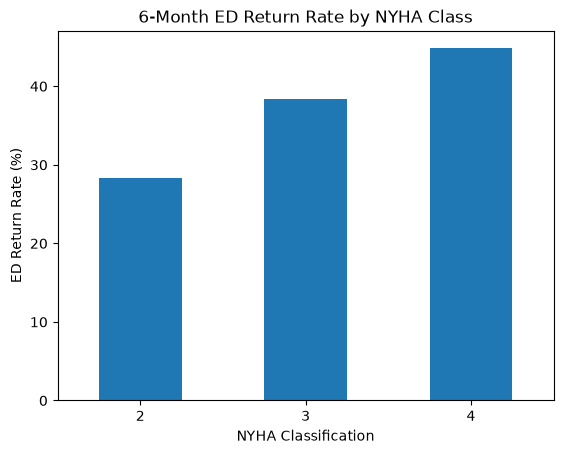

In [19]:
nyha_rate = (
    hf_df.groupby("nyha_cardiac_function_classification")[target]
    .mean()
    .mul(100)
)

nyha_rate.plot(kind="bar")

plt.title("6-Month ED Return Rate by NYHA Class")
plt.xlabel("NYHA Classification")
plt.ylabel("ED Return Rate (%)")
plt.xticks(rotation=0)
plt.show()

##### ***Hypothesis Testing — Kidney Function(creatinine).***
##### ***H₀*** - ***Creatinine levels do not differ significantly between patients who return to the ED and those who do not.***
##### ***H₁*** - ***Creatinine levels differ significantly between patients who return and those who do not.***

Median - ED Return: 93.85
Median - No ED Return: 82.8
P-value: 0.0
Reject H0: Significant difference exists.


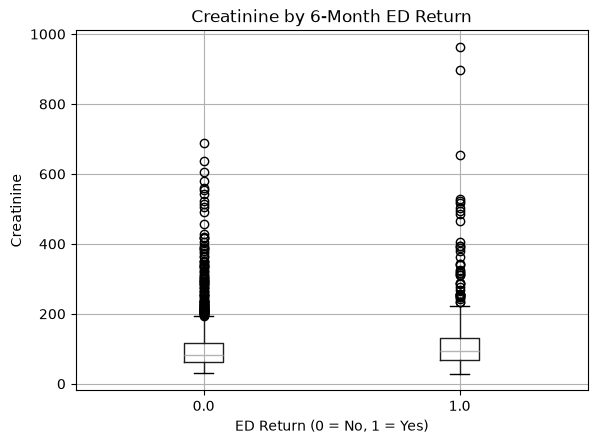

In [20]:


returned = hf_df.loc[
    hf_df[target] == 1,
    "creatinine"
].dropna()

not_returned = hf_df.loc[
    hf_df[target] == 0,
    "creatinine"
].dropna()

stat, p = mannwhitneyu(
    returned,
    not_returned,
    alternative="two-sided"
)

print("Median - ED Return:",
      round(returned.median(), 2))

print("Median - No ED Return:",
      round(not_returned.median(), 2))

print("P-value:", round(p, 5))

if p < 0.05:
    print("Reject H0: Significant difference exists.")
else:
    print("Fail to reject H0: No significant difference found.")


hf_df.boxplot(
    column="creatinine",
    by=target
)

plt.title("Creatinine by 6-Month ED Return")
plt.suptitle("")
plt.xlabel("ED Return (0 = No, 1 = Yes)")
plt.ylabel("Creatinine")
plt.show()    

##### ***Insight: Higher creatinine levels were observed among patients who returned to the ED within six months. The statistically significant difference (p < 0.001) supports including creatinine as a potential predictor of ED return.***

In [21]:
# Data for Prediction
model_df = hf_df[features + [target]].dropna()

print("Rows available for modeling:", len(model_df))

X = model_df[features]
y = model_df[target]

print("\nTarget distribution:")
print(y.value_counts())


# Encode Categorical varaiables
X = pd.get_dummies(
    X,
    columns=["nyha_cardiac_function_classification"],
    drop_first=True
)

display(X.head())

# Train and test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

#Standardize the Numeric values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Logistic Regression Model
model = LogisticRegression(
    max_iter=2000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]




Rows available for modeling: 1934

Target distribution:
ed_return_6mo
0.0    1184
1.0     750
Name: count, dtype: int64


,lvef,cci_score,creatinine,gfr,pulse,respiration,systolic_bp,diastolic_bp,nyha_cardiac_function_classification_3,nyha_cardiac_function_classification_4
0,51.0,1.0,73.2,71.88,61.0,19.0,120.0,60.0,True,False
1,51.0,2.0,108.3,58.57,87.0,19.0,102.0,64.0,True,False
2,51.0,0.0,62.0,85.43,95.0,18.0,150.0,70.0,True,False
3,51.0,0.0,185.1,31.51,98.0,18.0,102.0,67.0,False,False
4,51.0,2.0,104.8,58.01,73.0,19.0,110.0,74.0,True,False


Training rows: 1547
Testing rows: 387


In [22]:
# Evaluate Model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob), 3)
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.592
ROC-AUC: 0.569

Classification Report:
              precision    recall  f1-score   support

         0.0       0.61      0.92      0.73       237
         1.0       0.38      0.08      0.13       150

    accuracy                           0.59       387
   macro avg       0.49      0.50      0.43       387
weighted avg       0.52      0.59      0.50       387


Confusion Matrix:
[[217  20]
 [138  12]]


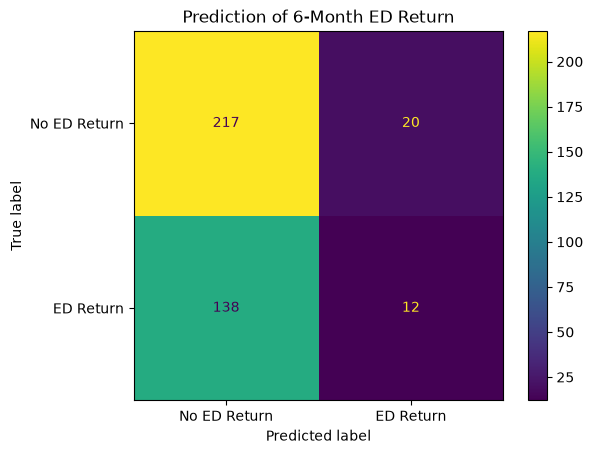

In [23]:
# CHarts 
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No ED Return",
        "ED Return"
    ]
)

plt.title("Prediction of 6-Month ED Return")
plt.show()

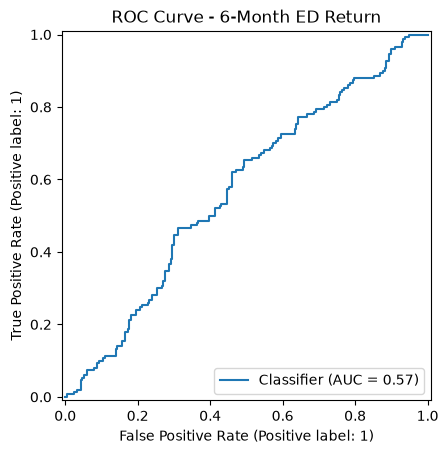

In [24]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - 6-Month ED Return")
plt.show()

### **The ROC curve shows the model's ability to distinguish between patients who returned to the ED and those who did not across different classification thresholds.**

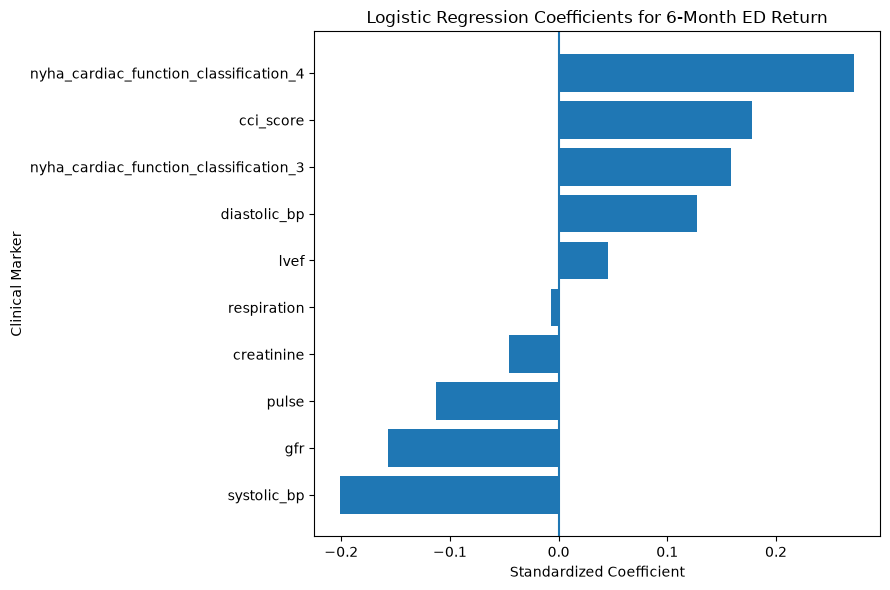

,Marker,Coefficient
6,systolic_bp,-0.201044
3,gfr,-0.156856
4,pulse,-0.112351
2,creatinine,-0.045809
5,respiration,-0.007430
0,lvef,0.045827
7,diastolic_bp,0.127098
8,nyha_cardiac_function_classification_3,0.158697
1,cci_score,0.178180
9,nyha_cardiac_function_classification_4,0.272031


In [25]:
# Model coefficients
coef_df = pd.DataFrame({
    "Marker": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient")

plt.figure(figsize=(9, 6))

plt.barh(
    coef_df["Marker"],
    coef_df["Coefficient"]
)

plt.axvline(0)

plt.title(
    "Logistic Regression Coefficients for 6-Month ED Return"
)

plt.xlabel("Standardized Coefficient")
plt.ylabel("Clinical Marker")

plt.tight_layout()
plt.show()

display(coef_df)

In [26]:
print("Accuracy:",
      round(accuracy_score(y_test, y_pred), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.592
ROC-AUC: 0.569

Classification Report:
              precision    recall  f1-score   support

         0.0       0.61      0.92      0.73       237
         1.0       0.38      0.08      0.13       150

    accuracy                           0.59       387
   macro avg       0.49      0.50      0.43       387
weighted avg       0.52      0.59      0.50       387


Confusion Matrix:
[[217  20]
 [138  12]]


### ***Positive coefficient → associated with higher predicted odds of ED return, holding other model variables constant.***
### ***Negative coefficient → associated with lower predicted odds, holding the others constant.***

##### ***Key Insights and Conclusion***

##### ***The hypothesis-testing stage identified statistically significant relationships between selected clinical characteristics and 6-month ED return. NYHA heart-failure severity was significantly associated with ED return (χ² = 25.729, p < 0.001), while patients who returned to the ED had higher median creatinine levels (93.85) than patients who did not return (82.80, p < 0.001).***

##### ***However, statistical significance did not translate into strong predictive performance. The Logistic Regression model achieved an accuracy of **59.2%** and an ROC-AUC of **0.569**, indicating limited ability to distinguish patients who returned to the ED from those who did not.***

##### ***The dataset also contained approximately **61% non-return patients**, meaning that accuracy alone is not sufficient for evaluating this model. Recall, precision, F1-score, the confusion matrix, and ROC-AUC should be considered together.***

##### ***Overall, heart-failure severity, kidney function, comorbidity burden, and vital signs contain information associated with ED return, but the selected markers alone were not sufficient to build a strong predictive model. Additional clinical, treatment, discharge, or follow-up variables and alternative modeling approaches could be investigated to improve predictive performance.***

##### ***Main Takeaway: Significant clinical associations can exist even when their combined predictive ability is limited. In this analysis, NYHA severity and creatinine were associated with ED return, but the Logistic Regression model showed that predicting individual 6-month ED returns remains challenging using these markers alone.***